# Deep-Reasoning

## 0. Setup

In [1]:
# Kaggle ya trae datasets/transformers. Solo falta el SDK de Gemini.
# SDK nuevo recomendado por Google: google-genai  (import: from google import genai)
!pip install -q -U google-genai datasets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.0/958.0 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.3/252.3 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 w

In [2]:
import os, re, json, time, random, textwrap
from datasets import load_dataset

random.seed(42)
print("listo")


listo


## 1. Cargar los datasets

Las dos fuentes oficiales del enunciado. Elegís **un** dominio para entrenar;
acá cargo los dos para que veas la diferencia y decidas.
- `openai/gsm8k`  → razonamiento matemático (gold = número final tras `####`)
- `google-research-datasets/mbpp` → razonamiento en código (gold = `test_list`, asserts)


In [3]:
# GSM8K: config "main", split train
gsm8k = load_dataset("openai/gsm8k", "main", split="train")

# MBPP: config "full" (974 problemas). "sanitized" es un subconjunto curado (427).
mbpp = load_dataset("google-research-datasets/mbpp", "full", split="train")

print("GSM8K:", len(gsm8k), "| columnas:", gsm8k.column_names)
print("MBPP :", len(mbpp),  "| columnas:", mbpp.column_names)


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

...

Generating train split:   0%|          | 0/374 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/90 [00:00<?, ? examples/s]

Generating prompt split:   0%|          | 0/10 [00:00<?, ? examples/s]

GSM8K: 7473 | columnas: ['question', 'answer']
MBPP : 374 | columnas: ['task_id', 'text', 'code', 'test_list', 'test_setup_code', 'challenge_test_list']


## 2. Cinco ejemplos random de cada dataset

In [4]:
def show_gsm8k(ds, n=5):
    idxs = random.sample(range(len(ds)), n)
    for k, i in enumerate(idxs, 1):
        ex = ds[i]
        gold = ex["answer"].split("####")[-1].strip()
        print(f"\n===== GSM8K #{i}  (ejemplo {k}/{n}) =====")
        print("Q:", textwrap.fill(ex["question"], 90))
        print("Razonamiento gold:")
        print(textwrap.indent(ex["answer"].split("####")[0].strip(), "   "))
        print("GOLD final ->", gold)

show_gsm8k(gsm8k, 5)



===== GSM8K #5238  (ejemplo 1/5) =====
Q: For every 12 cans you recycle, you receive $0.50, and for every 5 kilograms of newspapers,
you receive $1.50. If your family collected 144 cans and 20 kilograms of newspapers, how
much money would you receive?
Razonamiento gold:
   There are 144/12 = <<144/12=12>>12 sets of 12 cans that the family collected.
   So, the family would receive $0.50 x 12 = $<<0.50*12=6>>6 for the cans.
   There are 20/5 = <<20/5=4>>4 sets of 5 kilograms of newspapers that the family collected.
   So, the family would receive $1.50 x 4 = $<<1.50*4=6>>6 for the newspapers.
   Therefore, the family would receive a total of $6 + $6 = $<<6+6=12>>12.
GOLD final -> 12

===== GSM8K #912  (ejemplo 2/5) =====
Q: Betty picked 16 strawberries. Matthew picked 20 more strawberries than Betty and twice as
many as Natalie. They used their strawberries to make jam. One jar of jam used 7
strawberries and they sold each jar at $4. How much money were they able to make from the
straw

In [5]:
def show_mbpp(ds, n=5):
    idxs = random.sample(range(len(ds)), n)
    for k, i in enumerate(idxs, 1):
        ex = ds[i]
        print(f"\n===== MBPP task_id={ex['task_id']}  (ejemplo {k}/{n}) =====")
        print("Prompt:", textwrap.fill(ex["text"], 90))
        print("Tests (gold):")
        for t in ex["test_list"]:
            print("   ", t)

show_mbpp(mbpp, 5)



===== MBPP task_id=726  (ejemplo 1/5) =====
Prompt: Write a function to multiply the adjacent elements of the given tuple.
Tests (gold):
    assert multiply_elements((1, 5, 7, 8, 10)) == (5, 35, 56, 80)
    assert multiply_elements((2, 4, 5, 6, 7)) == (8, 20, 30, 42)
    assert multiply_elements((12, 13, 14, 9, 15)) == (156, 182, 126, 135)

===== MBPP task_id=715  (ejemplo 2/5) =====
Prompt: Write a function to convert the given string of integers into a tuple.
Tests (gold):
    assert str_to_tuple("1, -5, 4, 6, 7") == (1, -5, 4, 6, 7)
    assert str_to_tuple("1, 2, 3, 4, 5") == (1, 2, 3, 4, 5)
    assert str_to_tuple("4, 6, 9, 11, 13, 14") == (4, 6, 9, 11, 13, 14)

===== MBPP task_id=672  (ejemplo 3/5) =====
Prompt: Write a function to find maximum of three numbers.
Tests (gold):
    assert max_of_three(10,20,30)==30
    assert max_of_three(55,47,39)==55
    assert max_of_three(10,49,30)==49

===== MBPP task_id=653  (ejemplo 4/5) =====
Prompt: Write a function to group a sequence of 

## 3. Template del teacher (inyección de la estructura de pensamiento)

Acá está el corazón conceptual de la Fase 1. Le exigimos al teacher que **piense
de a pasos** y que **se autocritique** antes de responder, usando 3 etiquetas:

- `<thinking>`  — razonamiento paso a paso (cadena de pensamiento)
- `<reflection>` — el modelo revisa su propio razonamiento y se corrige si hace falta
- `<answer>`    — respuesta final, limpia

El `<reflection>` es lo que imita el "pará, dejame revisar" de o1 / R1.
Pongo **un ejemplo few-shot** para fijar el formato: el student después copia
este formato exactamente, así que tiene que salir consistente.


In [6]:
SYSTEM_INSTRUCTION = """You are a meticulous reasoning tutor.
For every problem, you MUST answer using EXACTLY these three tags, in this order:

<thinking>
Reason step by step. Show every intermediate calculation.
</thinking>
<reflection>
Re-check your own reasoning above. Look for arithmetic slips or wrong assumptions.
If you find a mistake, correct it here explicitly.
</reflection>
<answer>
The final answer only. For math: just the final number. For code: just the function.
</answer>

Do not write anything outside these tags."""

FEWSHOT_USER = "Natalia sold clips to 48 friends in April, and half as many in May. How many clips altogether?"
FEWSHOT_ASSISTANT = """<thinking>
April = 48. May = half of April = 48 / 2 = 24. Total = 48 + 24 = 72.
</thinking>
<reflection>
Check: 48/2 = 24 correct. 48 + 24 = 72 correct. No mistakes.
</reflection>
<answer>
72
</answer>"""

def build_prompt(question: str) -> str:
    # Para GSM8K mandamos la pregunta tal cual.
    # Para MBPP convendría agregar "Write a Python function..." + los asserts.
    return question

print(SYSTEM_INSTRUCTION[:120], "...")


You are a meticulous reasoning tutor.
For every problem, you MUST answer using EXACTLY these three tags, in this order:
 ...


## 4. Conexión a la API del teacher (Gemini Flash)

**API key:** NO la pegues en el código. En Kaggle: `Add-ons → Secrets`, creá un
secreto `GEMINI_API_KEY` con tu key de Google AI Studio (tiene free tier).

> El nombre del modelo Flash cambia con el tiempo. Verificá el actual en
> ai.google.dev / AI Studio y ajustá `MODEL`. Dejo un default razonable.


In [9]:
#!pip install -q -U transformers peft bitsandbytes accelerate datasets \
#    google-genai "pydantic>=2.10" "pydantic-core>=2.27"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 31.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 31.4 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numb

In [7]:
from google import genai
from google.genai import types

# --- API key desde Kaggle Secrets (con fallback a variable de entorno) ---
try:
    from kaggle_secrets import UserSecretsClient
    API_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
except Exception:
    API_KEY = os.environ.get("GEMINI_API_KEY", "")

assert API_KEY, "Falta GEMINI_API_KEY (Kaggle Secrets o variable de entorno)."

MODEL = "gemini-2.5-flash"   # <-- verificá el nombre del Flash actual y cambialo si hace falta

client = genai.Client(api_key=API_KEY)

def ask_teacher(question, temperature=0.7, max_retries=5):
    cfg = types.GenerateContentConfig(
        system_instruction=SYSTEM_INSTRUCTION, temperature=temperature)
    for attempt in range(max_retries):
        try:
            r = client.models.generate_content(model=MODEL, contents=question, config=cfg)
            return r.text
        except Exception as e:
            wait = min(60, 8 * (attempt + 1))          # 8,16,24,... hasta 60s
            print(f"  [retry {attempt+1}/{max_retries}] {type(e).__name__}: {e}")  # <-- mensaje real
            time.sleep(wait)
    raise RuntimeError("Falló tras varios reintentos.")

# y en el loop, subí el sleep entre llamadas:
# sft = build_sft_dataset(gsm8k, n=8, sleep=7)   # ~1 llamada cada 7s = bajo 10/min

In [8]:
from google import genai
client = genai.Client(api_key=API_KEY)

for m in client.models.list():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

## 5. Ver qué responde la API en UN ejemplo

In [9]:
# Diagnóstico: llamada mínima, sin red de contención, para VER el error real
r = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="hi, solo hi",
)
print(r.text)

Hi there! 👋


In [10]:
sample = gsm8k[random.randrange(len(gsm8k))]
print("PREGUNTA:")
print(textwrap.fill(sample["question"], 90))
print("\nGOLD:", sample["answer"].split("####")[-1].strip())
print("\n--- RESPUESTA DEL TEACHER ---\n")

trace = ask_teacher(sample["question"])
#print(trace)


PREGUNTA:
Michael has 36 pets. 25% of them are dogs, 50% are cats, and the rest are bunnies. How
many bunnies does he have?

GOLD: 9

--- RESPUESTA DEL TEACHER ---



## 6. Filtro de rechazo (rejection sampling)

Esta es la idea *raíz*: **descartamos toda traza cuyo `<answer>` no coincide con
el gold.** Solo entrenamos al student con trazas correctas. La calidad del dataset
domina todo lo de abajo.


In [12]:
def extract_tag(text: str, tag: str) -> str:
    m = re.search(fr"<{tag}>(.*?)</{tag}>", text, re.DOTALL | re.IGNORECASE)
    return m.group(1).strip() if m else ""

def normalize_number(s: str) -> str:
    # deja solo el número final: saca $, comas, texto
    nums = re.findall(r"-?\d[\d,]*\.?\d*", s.replace(",", ""))
    return nums[-1] if nums else ""

def gsm8k_is_correct(trace: str, gold_answer_field: str) -> bool:
    gold = normalize_number(gold_answer_field.split("####")[-1])
    pred = normalize_number(extract_tag(trace, "answer"))
    return gold != "" and pred == gold

# probamos el filtro con la traza de arriba
#ok = gsm8k_is_correct(trace, sample["answer"])
#print("¿Traza correcta? ->", ok)
#print("pred:", normalize_number(extract_tag(trace, "answer")),
#      "| gold:", normalize_number(sample["answer"].split("####")[-1]))


### Filtro para MBPP (código)

Acá la verificación es ejecutar la función contra los `test_list`.
⚠️ **`exec` es inseguro.** Para un proyecto real, corré el código en un subproceso
aislado con timeout (o `RestrictedPython` / un sandbox). Esta versión mínima sirve
para prototipar, no para producción.


In [13]:
def mbpp_is_correct(generated_code: str, test_list, setup_code: str = "", timeout_note=True) -> bool:
    # ⚠️ exec inseguro — ver nota arriba. Solo para prototipo.
    ns = {}
    try:
        if setup_code:
            exec(setup_code, ns)
        exec(generated_code, ns)
        for assertion in test_list:
            exec(assertion, ns)
        return True
    except Exception:
        return False

# demo con el código gold de un ejemplo (debería dar True)
m = mbpp[0]
print("MBPP gold pasa sus tests:", mbpp_is_correct(m["code"], m["test_list"], m.get("test_setup_code","")))


MBPP gold pasa sus tests: True


In [ ]:
import os

OUT_PATH = "/kaggle/working/sft_reasoning.jsonl"

def load_progress():
    """Lee lo ya hecho para poder reanudar."""
    done_idx, kept = set(), 0
    if os.path.exists(OUT_PATH):
        for line in open(OUT_PATH):
            done_idx.add(json.loads(line)["idx"]); kept += 1
    return done_idx, kept

def generate_until(ds, target_kept=200, sleep=7, log_every=10):
    done_idx, kept = load_progress()
    print(f"Reanudando: {kept} ya guardadas, {len(done_idx)} índices usados")
    pool = [i for i in range(len(ds)) if i not in done_idx]
    random.shuffle(pool)

    attempts = 0
    with open(OUT_PATH, "a") as f:          # modo APPEND = no pisa lo anterior
        for i in pool:
            if kept >= target_kept:
                break
            try:
                trace = ask_teacher(ds[i]["question"])
            except Exception as e:
                print(f"  idx {i}: error, salto -> {e}")
                time.sleep(sleep); continue
            attempts += 1
            if gsm8k_is_correct(trace, ds[i]["answer"]):
                f.write(json.dumps({"idx": i,
                                    "question": ds[i]["question"],
                                    "trace": trace}, ensure_ascii=False) + "\n")
                f.flush()                    # <-- ESCRIBE A DISCO YA, no espera al final
                kept += 1
            if attempts % log_every == 0:
                print(f"  intentos={attempts} | guardadas={kept}/{target_kept} | tasa={kept/attempts:.0%}")
            time.sleep(sleep)
    print(f"\nListo: {kept} trazas en {OUT_PATH}")

generate_until(gsm8k, target_kept=500, sleep=1.5)

Reanudando: 21 ya guardadas, 21 índices usados
  intentos=10 | guardadas=28/500 | tasa=280%


## 7. Ensamblar el dataset SFT (loop chico)

Generamos trazas para N preguntas, filtramos, y guardamos solo las correctas como
tuplas `(question, teacher_trace)`. Empezá con N chico (5–10) para no quemar la
free tier; cuando funcione, escalás.


In [ ]:
# Guardar a disco (esto es tu "database" de la Fase 1)
OUT = "/kaggle/working/sft_reasoning.jsonl"
with open(OUT, "w") as f:
    for row in sft:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
print("guardado en", OUT, "->", len(sft), "ejemplos")


# 8. Setup

In [1]:
!pip install -q -U transformers peft bitsandbytes accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 81.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 68.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which i

In [2]:
import os, json, torch
from datasets import Dataset
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          BitsAndBytesConfig, TrainingArguments, Trainer,
                          DataCollatorForSeq2Seq)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

print("CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA: True | Tesla T4


## 9. Cargar el dataset de la Fase 1

Subí tu `sft_reasoning.jsonl` como dataset de Kaggle, o si corrés todo en el mismo
kernel, queda en `/kaggle/working/`. Ajustá la ruta.

In [5]:
PATH = "/kaggle/working/sft_reasoning.jsonl"   # <-- ajustá si lo subiste como dataset
rows = [json.loads(l) for l in open(PATH)]
print("ejemplos:", len(rows))
print("\nUn ejemplo:")
print("Q:", rows[0]["question"][:80], "...")
print("TRACE:", rows[0]["trace"][:200], "...")

# Mismo system prompt que usaste con el teacher (consistencia train/inference)
SYSTEM_INSTRUCTION = """You are a meticulous reasoning tutor.
For every problem, answer using EXACTLY these tags in order:
<thinking> step-by-step reasoning </thinking>
<reflection> re-check and correct your own reasoning </reflection>
<answer> final answer only </answer>
Do not write anything outside these tags."""

ejemplos: 21

Un ejemplo:
Q: A soccer team had 24 players prepared for a soccer game. The first half saw 11 p ...
TRACE: <thinking>
The problem asks us to find the number of players on the team who did not play that day.
First, we need to determine the total number of unique players who played.
The total number of playe ...


## 10. Cargar Qwen2.5-3B en 4-bit (QLoRA)

In [6]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

# Cuantización 4-bit (esto es la "Q" de QLoRA): el peso base vive en 4-bit NF4,
# pero los cálculos se hacen en fp16. Esto es lo que hace que un 3B entre en una T4.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",          # NF4 = distribución pensada para pesos
    bnb_4bit_compute_dtype=torch.float16,  # T4 no tiene bf16 nativo -> fp16
    bnb_4bit_use_double_quant=True,     # cuantiza también las constantes (ahorra ~0.4 bit/peso)
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto"
)

model.config.use_cache = False          # necesario con gradient checkpointing
print("modelo cargado")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

modelo cargado


## 11.. Config de LoRA

`target_modules`: en qué matrices del transformer inyectamos los adaptadores. Para
Qwen son las proyecciones de atención (`q/k/v/o_proj`) y del MLP (`gate/up/down_proj`).

- `r=16` — rango: cuántos parámetros nuevos. Subilo si underfittea, bajalo si overfittea.
- `lora_alpha=32` — escala lo aprendido (regla común: alpha ≈ 2·r).
- `lora_dropout=0.05` — regularización suave.

**Hipótesis para vos:** ¿qué pasa con r=8 vs r=32? ¿La curva de loss baja distinto?
Anotá tu predicción ANTES de correr y comparala. Eso es el músculo que querés entrenar.

In [36]:
model = prepare_model_for_kbit_training(model)  # arregla layernorms/grads para 4-bit

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj",
                    "gate_proj","up_proj","down_proj"],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()   # mirá: entrenás <1% de los parámetros

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


## 12.. Chat template + loss mask

Esta es **la** celda del proyecto. Dos pasos:

1. Armamos el texto con el **chat template** de Qwen: `system + user + assistant`.
2. Construimos `labels` con **-100 en todo el prompt** y los ids reales solo en la
   respuesta del assistant. PyTorch ignora `-100` al calcular la pérdida.

El truco para encontrar el límite: tokenizamos el texto COMPLETO, y por separado
tokenizamos SOLO el prompt (hasta justo antes de la respuesta). El prompt tiene que
ser un prefijo exacto del completo — por eso el `assert`. Las posiciones del prompt
van a -100; el resto queda como está.

In [37]:
MAX_LEN = 1024

def tokenize_example(ex):
    messages = [
        {"role": "system",    "content": SYSTEM_INSTRUCTION},
        {"role": "user",      "content": ex["question"]},
        {"role": "assistant", "content": ex["trace"]},
    ]
    
    # texto completo (incluye la respuesta del assistant)
    full = tokenizer.apply_chat_template(messages, tokenize=False)
    
    # texto SOLO del prompt: system + user + "header" del assistant, sin la respuesta
    prompt = tokenizer.apply_chat_template(messages[:-1], tokenize=False,
                                           add_generation_prompt=True)

    full_ids   = tokenizer(full,   add_special_tokens=False, truncation=True, max_length=MAX_LEN)["input_ids"]
    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]

    # el prompt DEBE ser prefijo exacto del completo
    assert full_ids[:len(prompt_ids)] == prompt_ids, "El prompt no es prefijo del completo (revisá el template)"

    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]
    return {"input_ids": full_ids,
            "labels": labels,
            "attention_mask": [1] * len(full_ids)}

ds = Dataset.from_list(rows).map(tokenize_example, remove_columns=["idx","question","trace"])
print(ds)

Map:   0%|          | 0/21 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'labels', 'attention_mask'],
    num_rows: 21
})


### Verificación del mask (vele la cara al bug antes de que exista)

Decodificamos un ejemplo separando lo enmascarado (-100, NO entra a la loss) de lo
que sí se entrena. Si el bloque "SE ENTRENA" no es exactamente la traza con sus
etiquetas, hay un problema.

In [38]:
ex = ds[0]
ignored = [t for t, l in zip(ex["input_ids"], ex["labels"]) if l == -100]
trained = [t for t, l in zip(ex["input_ids"], ex["labels"]) if l != -100]

print("=== ENMASCARADO (prompt, label=-100, NO entra a la loss) ===")
print(tokenizer.decode(ignored))
print("\n=== SE ENTRENA (la traza del assistant) ===")
print(tokenizer.decode(trained))

=== ENMASCARADO (prompt, label=-100, NO entra a la loss) ===
<|im_start|>system
You are a meticulous reasoning tutor.
For every problem, answer using EXACTLY these tags in order:
<thinking> step-by-step reasoning </thinking>
<reflection> re-check and correct your own reasoning </reflection>
<answer> final answer only </answer>
Do not write anything outside these tags.<|im_end|>
<|im_start|>user
A soccer team had 24 players prepared for a soccer game. The first half saw 11 players start the game with 2 substitutions made. In the second half, the team made twice as many substitutions as it made in the first half. How many players on the team did not play that day?<|im_end|>
<|im_start|>assistant


=== SE ENTRENA (la traza del assistant) ===
<thinking>
The problem asks us to find the number of players on the team who did not play that day.
First, we need to determine the total number of unique players who played.
The total number of players prepared for the game is 24.

In the first half:

In [39]:
# split chico train/val para mirar generalización
ds = ds.train_test_split(test_size=0.01, seed=42)
print(ds)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'labels', 'attention_mask'],
        num_rows: 20
    })
    test: Dataset({
        features: ['input_ids', 'labels', 'attention_mask'],
        num_rows: 1
    })
})


In [42]:
collator = DataCollatorForSeq2Seq(tokenizer, padding=True, label_pad_token_id=-100)

args = TrainingArguments(
    output_dir="/kaggle/working/qwen-reasoning-lora",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,      # batch efectivo = 16
    num_train_epochs=3,
    learning_rate=2e-4,                 # LR típico de LoRA (mucho más alto que full-FT)
    lr_scheduler_type="cosine",
    warmup_steps=0.03,
    fp16=True,                          # T4; si tenés A100/L4 usá bf16=True y fp16=False
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=ds["train"], eval_dataset=ds["test"],
    data_collator=collator,
)
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.575951
2,No log,0.515221
3,0.660360,0.502575


TrainOutput(global_step=6, training_loss=0.63212850689888, metrics={'train_runtime': 112.7997, 'train_samples_per_second': 0.532, 'train_steps_per_second': 0.053, 'total_flos': 867798884941824.0, 'train_loss': 0.63212850689888, 'epoch': 3.0})

## 13. Curva de pérdida

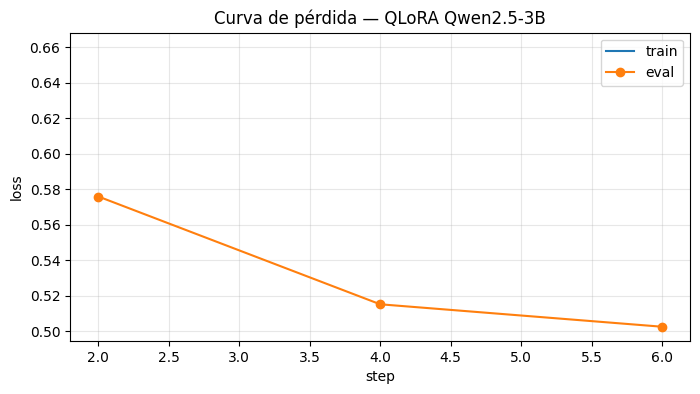

In [43]:
import matplotlib.pyplot as plt

hist = trainer.state.log_history
train = [(h["step"], h["loss"]) for h in hist if "loss" in h]
evals = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

plt.figure(figsize=(8,4))
if train: plt.plot(*zip(*train), label="train")
if evals: plt.plot(*zip(*evals), "o-", label="eval")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=.3)
plt.title("Curva de pérdida — QLoRA Qwen2.5-3B")
plt.show()

## 14. Guardar los adaptadores

In [52]:
OUT = "/kaggle/working/qwen-reasoning-lora-final"
trainer.model.save_pretrained(OUT)
tokenizer.save_pretrained(OUT)
print("adaptadores guardados en", OUT)
# Pesan poco (MBs): es solo B y A, no el modelo entero.

adaptadores guardados en /kaggle/working/qwen-reasoning-lora-final


## 15. Prueba rápida de inferencia

In [7]:
def generate(question, max_new_tokens=512, temperature=0.7):
    messages = [
        {"role": "system", "content": SYSTEM_INSTRUCTION},
        {"role": "user",   "content": question},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt",
        return_dict=True            # <-- pide el dict explícito (input_ids + attention_mask)
    ).to(model.device)

    model.config.use_cache = True
    out = model.generate(**inputs,  # <-- desempaqueta el dict: pasa ids Y attention_mask
                         max_new_tokens=max_new_tokens,
                         temperature=temperature, do_sample=True,
                         pad_token_id=tokenizer.pad_token_id)
    model.config.use_cache = False

    # el largo del prompt sale de input_ids, no de "inputs"
    prompt_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)

print(generate(q))

NameError: name 'q' is not defined

## 16 Setup

In [ ]:
!pip install -q -U transformers peft bitsandbytes accelerate datasets

In [8]:
import os, re, json, torch, random
from collections import Counter
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

MODEL_ID     = "Qwen/Qwen2.5-3B-Instruct"
ADAPTER_PATH = "/kaggle/working/qwen-reasoning-lora-final"  # <-- salida de la Fase 2

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base  = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb, device_map="auto")
model = PeftModel.from_pretrained(base, ADAPTER_PATH)   # base 4-bit + adaptadores LoRA
model.eval()

SYSTEM_INSTRUCTION = """You are a meticulous reasoning tutor.
For every problem, answer using EXACTLY these tags in order:
<thinking> step-by-step reasoning </thinking>
<reflection> re-check and correct your own reasoning </reflection>
<answer> final answer only </answer>
Do not write anything outside these tags."""
print("modelo ajustado cargado")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

modelo ajustado cargado


In [9]:
# dataset de TEST (nunca lo viste en training) + helpers de parsing
gsm8k_test = load_dataset("openai/gsm8k", "main", split="test")

def extract_tag(text, tag):
    m = re.search(fr"<{tag}>(.*?)</{tag}>", text, re.DOTALL | re.IGNORECASE)
    return m.group(1).strip() if m else ""

def normalize_number(s):
    nums = re.findall(r"-?\d[\d,]*\.?\d*", s.replace(",", ""))
    return nums[-1] if nums else ""

print("test:", len(gsm8k_test), "problemas")

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

test: 1319 problemas


## 17. Muestrear N trazas para un mismo problema

Clave: `temperature > 0` y `do_sample=True`, para que las N trazas sean **distintas**
(con temperatura 0 saldrían todas iguales y el voto no tendría sentido).
`num_return_sequences=N` genera las N de una sola pasada.

In [16]:
@torch.no_grad()
def sample_traces(question, n=10, temperature=0.8, max_new_tokens=512):
    messages = [{"role": "system", "content": SYSTEM_INSTRUCTION},
                {"role": "user",   "content": question}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt",
        return_dict=True              # <-- pide el dict
    ).to(model.device)

    out = model.generate(**inputs,    # <-- desempaqueta: ids + attention_mask
                         max_new_tokens=max_new_tokens,
                         do_sample=True, temperature=temperature,
                         num_return_sequences=n,
                         pad_token_id=tokenizer.pad_token_id)

    prompt_len = inputs["input_ids"].shape[1]   # <-- shape sale de input_ids
    return [tokenizer.decode(o[prompt_len:], skip_special_tokens=True) for o in out]

## 18. Majority voting (self-consistency)

De cada traza extraemos el número del `<answer>`, descartamos las vacías, y votamos:
gana el número más frecuente.

In [17]:
def majority_answer(traces):
    answers = [normalize_number(extract_tag(t, "answer")) for t in traces]
    answers = [a for a in answers if a]          # descarta trazas sin respuesta válida
    if not answers:
        return None
    return Counter(answers).most_common(1)[0][0]

def self_consistency(question, n=10, temperature=0.8):
    return majority_answer(sample_traces(question, n=n, temperature=temperature))

### Demo en un problema: mirá cómo votan las trazas

In [18]:
ex = gsm8k_test[0]
traces = sample_traces(ex["question"], n=10)
answers = [normalize_number(extract_tag(t, "answer")) for t in traces]

print("PREGUNTA:", ex["question"][:90], "...")
print("GOLD:", normalize_number(ex["answer"].split("####")[-1]))
print("\nRespuestas de las 10 trazas:", answers)
print("Conteo de votos:", Counter([a for a in answers if a]))
print("GANADORA (majority):", majority_answer(traces))

PREGUNTA: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes mu ...
GOLD: 18

Respuestas de las 10 trazas: ['18', '18', '18', '18', '18', '18', '', '', '', '']
Conteo de votos: Counter({'18': 6})
GANADORA (majority): 18


## 19. Accuracy vs N — la curva del reporte

**Truco de eficiencia:** generamos N_MAX trazas UNA sola vez por problema, y después
calculamos el accuracy para cada N votando sobre las primeras N. Así no re-generamos
para cada valor de N (ahorra muchísimo cómputo).

In [ ]:
N_MAX      = 10
N_LIST     = [1, 3, 5, 7, 10]
N_PROBLEMS = 40          # subí esto para una medición más estable (más lento)

subset = gsm8k_test.select(range(N_PROBLEMS))

# generamos N_MAX trazas por problema, una vez
all_traces = []
for k, ex in enumerate(subset):
    all_traces.append(sample_traces(ex["question"], n=N_MAX))
    if (k+1) % 10 == 0:
        print(f"  generadas trazas para {k+1}/{N_PROBLEMS} problemas")

# accuracy para cada N, reusando las mismas trazas
acc_by_n = {}
for N in N_LIST:
    correct = 0
    for ex, traces in zip(subset, all_traces):
        gold = normalize_number(ex["answer"].split("####")[-1])
        if majority_answer(traces[:N]) == gold:
            correct += 1
    acc_by_n[N] = correct / len(subset)

print("\naccuracy por N:", acc_by_n)

In [ ]:
import matplotlib.pyplot as plt

Ns  = list(acc_by_n.keys())
acc = [acc_by_n[n]*100 for n in Ns]

plt.figure(figsize=(7,4))
plt.plot(Ns, acc, "o-", linewidth=2)
plt.xlabel("N (trazas votadas)"); plt.ylabel("Accuracy (%)")
plt.title("Self-Consistency: accuracy vs N de votos (GSM8K)")
plt.grid(alpha=.3)
for n, a in zip(Ns, acc):
    plt.annotate(f"{a:.0f}%", (n, a), textcoords="offset points", xytext=(0,8))
plt.show()
# Esperás: sube rápido de N=1 a N=5, después se aplana (rendimientos decrecientes).

## 20. Win rate: modelo ajustado vs. base

Comparamos accuracy (a N=1, sin voto) del student ajustado contra el modelo de fábrica.
**Truco:** con `model.disable_adapter()` apagamos LoRA temporalmente y obtenemos el
comportamiento del base, sin cargar un segundo modelo en memoria.

In [ ]:
def accuracy_n1(dataset, use_adapter=True):
    correct = 0
    for ex in dataset:
        gold = normalize_number(ex["answer"].split("####")[-1])
        if use_adapter:
            pred = majority_answer(sample_traces(ex["question"], n=1, temperature=0.0 if False else 0.7))
        else:
            with model.disable_adapter():
                pred = majority_answer(sample_traces(ex["question"], n=1, temperature=0.7))
        if pred == gold:
            correct += 1
    return correct / len(dataset)

eval_set = gsm8k_test.select(range(40))
acc_ft   = accuracy_n1(eval_set, use_adapter=True)
acc_base = accuracy_n1(eval_set, use_adapter=False)
print(f"Ajustado (LoRA): {acc_ft:.0%}")
print(f"Base (fábrica) : {acc_base:.0%}")
print(f"Diferencia     : {(acc_ft-acc_base)*100:+.0f} puntos")

## 21. LLM-as-judge (rigor del CoT y autocorrección)

Para lo que **no** podés verificar con el número (¿el razonamiento es riguroso?,
¿el `<reflection>` realmente corrige?), usamos un LLM externo de juez. Pedimos que
devuelva JSON estricto para poder parsearlo.

> Necesitás de nuevo `GEMINI_API_KEY` en Kaggle Secrets.

In [ ]:
from google import genai
from google.genai import types

try:
    from kaggle_secrets import UserSecretsClient
    API_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
except Exception:
    API_KEY = os.environ.get("GEMINI_API_KEY", "")

judge = genai.Client(api_key=API_KEY)
JUDGE_MODEL = "gemini-2.5-flash"

JUDGE_PROMPT = """You are evaluating a model's reasoning trace.
Return ONLY valid JSON, no markdown, with these keys:
- "cot_rigor": int 0-100 (is the step-by-step reasoning sound and complete?)
- "self_correction": true/false (does the reflection catch or fix any mistake?)
- "comment": one short sentence.

Problem: {q}
Trace: {t}"""

def judge_trace(question, trace):
    prompt = JUDGE_PROMPT.format(q=question, t=trace)
    r = judge.models.generate_content(model=JUDGE_MODEL, contents=prompt)
    txt = r.text.replace("```json", "").replace("```", "").strip()
    try:
        return json.loads(txt)
    except Exception:
        return {"error": "no parseó", "raw": txt[:200]}

# demo en una traza
ex = gsm8k_test[1]
one = sample_traces(ex["question"], n=1)[0]
print(judge_trace(ex["question"], one))